# MILESTONE 1

In [ ]:
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)


In [ ]:
file_path = "/content/flights_dataset.csv"

df = pd.read_csv(file_path,low_memory=False)


In [ ]:
print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (5819079, 31)
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   
2  2015      1    1            4      US            840      N171US   
3  2015      1    1            4      AA            258      N3HYAA   
4  2015      1    1            4      AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  DEPARTURE_TIME  \
0            ANC                 SEA                    5          2354.0   
1            LAX                 PBI                   10             2.0   
2            SFO                 CLT                   20            18.0   
3            LAX                 MIA                   20            15.0   
4            SEA                 ANC                   25            24.0   

   DEPARTURE_DELAY  TAXI_OUT  WHEELS_OFF  SCHEDULED_TIME  ELAPSED_TIME  \
0            -1

In [ ]:
print("\nColumn Names:")
print(df.columns)

print("\nStatistical Summary:")
print(df.describe())


Column Names:
Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

Statistical Summary:
            YEAR         MONTH           DAY   DAY_OF_WEEK  FLIGHT_NUMBER  \
count  5819079.0  5.819079e+06  5.819079e+06  5.819079e+06   5.819079e+06   
mean      2015.0  6.524085e+00  1.570459e+01  3.926941e+00   2.173093e+03   
std          0.0  3.405137e+00  8.783425e+00  1.988845e+00   1.757064e+03   
min       2015.0  1.000000e+00  1.000000e+00  1.000000e+00   1.000000e+00   
25%       2

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print("\nMissing Values:")
print(missing)

print("\nMissing Percentage:")
print((df.isnull().mean()*100).round(2))



Missing Values:
CANCELLATION_REASON    5729195
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
AIRLINE_DELAY          4755640
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
ELAPSED_TIME            105071
AIR_TIME                105071
ARRIVAL_DELAY           105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
WHEELS_OFF               89047
TAXI_OUT                 89047
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
DESTINATION_AIRPORT          0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
MONTH                        0
ORIGIN_AIRPORT               0
SCHEDULED_DEPARTURE          0
YEAR                         0
SCHEDULED_ARRIVAL            0
DISTANCE                     0
DIVERTED                     0
CANCELLED                    0
dtype: int64

Missing 

In [ ]:
cat_cols = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "CANCELLATION_REASON"
]

for col in cat_cols:
    df[col] = df[col].astype("category")


In [ ]:
df["YEAR"] = df["YEAR"].astype("int16")
df["MONTH"] = df["MONTH"].astype("int8")
df["DAY"] = df["DAY"].astype("int8")
df["DAY_OF_WEEK"] = df["DAY_OF_WEEK"].astype("int8")
print("\nUpdated Data Types:")
print(df.dtypes)

print("\nMemory Usage (MB):")
print(df.memory_usage(deep=True).sum()/1024**2)


Updated Data Types:
YEAR                      int16
MONTH                      int8
DAY                        int8
DAY_OF_WEEK                int8
AIRLINE                category
FLIGHT_NUMBER             int64
TAIL_NUMBER              object
ORIGIN_AIRPORT         category
DESTINATION_AIRPORT    category
SCHEDULED_DEPARTURE       int64
DEPARTURE_TIME          float64
DEPARTURE_DELAY         float64
TAXI_OUT                float64
WHEELS_OFF              float64
SCHEDULED_TIME          float64
ELAPSED_TIME            float64
AIR_TIME                float64
DISTANCE                  int64
WHEELS_ON               float64
TAXI_IN                 float64
SCHEDULED_ARRIVAL         int64
ARRIVAL_TIME            float64
ARRIVAL_DELAY           float64
DIVERTED                  int64
CANCELLED                 int64
CANCELLATION_REASON    category
AIR_SYSTEM_DELAY        float64
SECURITY_DELAY          float64
AIRLINE_DELAY           float64
LATE_AIRCRAFT_DELAY     float64
WEATHER_DELAY      

In [ ]:
delay_cols = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

df.loc[df["CANCELLED"] == 1, delay_cols] = np.nan
df[delay_cols] = df[delay_cols].fillna(0)
df["CANCELLATION_REASON"] = df["CANCELLATION_REASON"].cat.add_categories("Not Cancelled")
df["CANCELLATION_REASON"] = df["CANCELLATION_REASON"].fillna("Not Cancelled")
print("\nRemaining Null Values:")
print(df.isnull().sum())

print("\nCancellation Reason Counts:")
print(df["CANCELLATION_REASON"].value_counts())


Remaining Null Values:
YEAR                        0
MONTH                       0
DAY                         0
DAY_OF_WEEK                 0
AIRLINE                     0
FLIGHT_NUMBER               0
TAIL_NUMBER             14721
ORIGIN_AIRPORT              0
DESTINATION_AIRPORT         0
SCHEDULED_DEPARTURE         0
DEPARTURE_TIME          86153
DEPARTURE_DELAY             0
TAXI_OUT                89047
WHEELS_OFF              89047
SCHEDULED_TIME              6
ELAPSED_TIME           105071
AIR_TIME               105071
DISTANCE                    0
WHEELS_ON               92513
TAXI_IN                 92513
SCHEDULED_ARRIVAL           0
ARRIVAL_TIME            92513
ARRIVAL_DELAY               0
DIVERTED                    0
CANCELLED                   0
CANCELLATION_REASON         0
AIR_SYSTEM_DELAY            0
SECURITY_DELAY              0
AIRLINE_DELAY               0
LATE_AIRCRAFT_DELAY         0
WEATHER_DELAY               0
dtype: int64

Cancellation Reason Counts:
CANC

In [ ]:
df["DATE"] = pd.to_datetime(
    df[["YEAR","MONTH","DAY"]]
)
print(df[["YEAR","MONTH","DAY","DATE"]].head())
print("Datatype:", df["DATE"].dtype)


   YEAR  MONTH  DAY       DATE
0  2015      1    1 2015-01-01
1  2015      1    1 2015-01-01
2  2015      1    1 2015-01-01
3  2015      1    1 2015-01-01
4  2015      1    1 2015-01-01
Datatype: datetime64[ns]


In [ ]:
df["MONTH_NAME"] = df["DATE"].dt.month_name()
print(df[["DATE","MONTH_NAME"]].head())


        DATE MONTH_NAME
0 2015-01-01    January
1 2015-01-01    January
2 2015-01-01    January
3 2015-01-01    January
4 2015-01-01    January


In [ ]:
df["DAY_NAME"] = df["DATE"].dt.day_name()
print(df[["DATE","DAY_NAME"]].head())

        DATE  DAY_NAME
0 2015-01-01  Thursday
1 2015-01-01  Thursday
2 2015-01-01  Thursday
3 2015-01-01  Thursday
4 2015-01-01  Thursday


In [ ]:
df["DEP_HOUR"] = df["SCHEDULED_DEPARTURE"] // 100
print(df[["SCHEDULED_DEPARTURE","DEP_HOUR"]].head())


   SCHEDULED_DEPARTURE  DEP_HOUR
0                    5         0
1                   10         0
2                   20         0
3                   20         0
4                   25         0


In [ ]:
df["ROUTE"] = (
    df["ORIGIN_AIRPORT"].astype(str)
    + "-" +
    df["DESTINATION_AIRPORT"].astype(str)
)
print(df[["ORIGIN_AIRPORT","DESTINATION_AIRPORT","ROUTE"]].head())


  ORIGIN_AIRPORT DESTINATION_AIRPORT    ROUTE
0            ANC                 SEA  ANC-SEA
1            LAX                 PBI  LAX-PBI
2            SFO                 CLT  SFO-CLT
3            LAX                 MIA  LAX-MIA
4            SEA                 ANC  SEA-ANC


In [ ]:
df["DELAY_STATUS"] = np.where(
    df["ARRIVAL_DELAY"] > 15,
    "Delayed",
    "On Time"
)
print(df["DELAY_STATUS"].value_counts())


DELAY_STATUS
On Time    4795581
Delayed    1023498
Name: count, dtype: int64


In [ ]:
drop_cols = [
    "TAIL_NUMBER",
    "FLIGHT_NUMBER",
    "WHEELS_OFF",
    "WHEELS_ON",
    "TAXI_OUT",
    "TAXI_IN",
    "AIR_TIME",
    "ELAPSED_TIME"
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")
print("Remaining Columns:")
print(df.columns)

print("New Shape:", df.shape)



Remaining Columns:
Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL',
       'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED',
       'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
       'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DATE',
       'MONTH_NAME', 'DAY_NAME', 'DEP_HOUR', 'ROUTE', 'DELAY_STATUS'],
      dtype='object')
New Shape: (5819079, 29)


In [ ]:
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (5819078, 29)


In [ ]:
print("\nFinal Preview:")
print(df.head())

print("\nFinal Info:")
print(df.info())

print("\nFinal Missing Values:")
print(df.isnull().sum().sort_values(ascending=False))



Final Preview:
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  \
0  2015      1    1            4      AS            ANC                 SEA   
1  2015      1    1            4      AA            LAX                 PBI   
2  2015      1    1            4      US            SFO                 CLT   
3  2015      1    1            4      AA            LAX                 MIA   
4  2015      1    1            4      AS            SEA                 ANC   

   SCHEDULED_DEPARTURE  DEPARTURE_TIME  DEPARTURE_DELAY  SCHEDULED_TIME  \
0                    5          2354.0            -11.0           205.0   
1                   10             2.0             -8.0           280.0   
2                   20            18.0             -2.0           286.0   
3                   20            15.0             -5.0           285.0   
4                   25            24.0             -1.0           235.0   

   DISTANCE  SCHEDULED_ARRIVAL  ARRIVAL_TIME  ARRIVAL_DELA

In [ ]:
# Save cleaned dataset
save_path = r"D:\Internship\Infosys Sprinboard\Airline-Analytics\flights_cleaned_1.csv"

df.to_parquet(save_path, index=False)

# Reload to verify
test_df = pd.read_parquet(save_path)

print(test_df.head())
print(test_df.shape)


   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  \
0  2015      1    1            4      AS            ANC                 SEA   
1  2015      1    1            4      AA            LAX                 PBI   
2  2015      1    1            4      US            SFO                 CLT   
3  2015      1    1            4      AA            LAX                 MIA   
4  2015      1    1            4      AS            SEA                 ANC   

   SCHEDULED_DEPARTURE  DEPARTURE_TIME  DEPARTURE_DELAY  SCHEDULED_TIME  \
0                    5          2354.0            -11.0           205.0   
1                   10             2.0             -8.0           280.0   
2                   20            18.0             -2.0           286.0   
3                   20            15.0             -5.0           285.0   
4                   25            24.0             -1.0           235.0   

   DISTANCE  SCHEDULED_ARRIVAL  ARRIVAL_TIME  ARRIVAL_DELAY  DIVERTED  \
0

# MILESTONE 2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.set_style("whitegrid")

In [ ]:
df = pd.read_parquet("/content/Cleaned Dataset .csv")
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,MONTH_NAME,DAY_NAME,DEP_HOUR,ROUTE,DELAY_STATUS
0,2015,1,1,4,AS,ANC,SEA,5,2354.0,-11.0,205.0,1448,430,408.0,-22.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,ANC-SEA,On Time
1,2015,1,1,4,AA,LAX,PBI,10,2.0,-8.0,280.0,2330,750,741.0,-9.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,LAX-PBI,On Time
2,2015,1,1,4,US,SFO,CLT,20,18.0,-2.0,286.0,2296,806,811.0,5.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,SFO-CLT,On Time
3,2015,1,1,4,AA,LAX,MIA,20,15.0,-5.0,285.0,2342,805,756.0,-9.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,LAX-MIA,On Time
4,2015,1,1,4,AS,SEA,ANC,25,24.0,-1.0,235.0,1448,320,259.0,-21.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,SEA-ANC,On Time


In [ ]:
df_delay = df[df['CANCELLED'] == 0].copy()
delay_cols = [
    'DEPARTURE_DELAY','ARRIVAL_DELAY','AIR_SYSTEM_DELAY',
    'SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY'
]
df_delay[delay_cols] = df_delay[delay_cols].fillna(0)

In [ ]:
df['MONTH_NAME'] = pd.to_datetime(df['MONTH'], format='%m').dt.month_name()

day_map = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}
df['DAY_NAME'] = df['DAY_OF_WEEK'].map(day_map)

df['DEPARTURE_HOUR'] = df['SCHEDULED_DEPARTURE'] // 100

def time_bucket(h):
    if h < 6: return "Late Night"
    elif h < 12: return "Morning"
    elif h < 18: return "Afternoon"
    else: return "Evening"

df['TIME_OF_DAY'] = df['DEPARTURE_HOUR'].apply(time_bucket)

df['ROUTE'] = df['ORIGIN_AIRPORT'].astype(str) + " → " + df['DESTINATION_AIRPORT'].astype(str)

TOP 10 Airlines

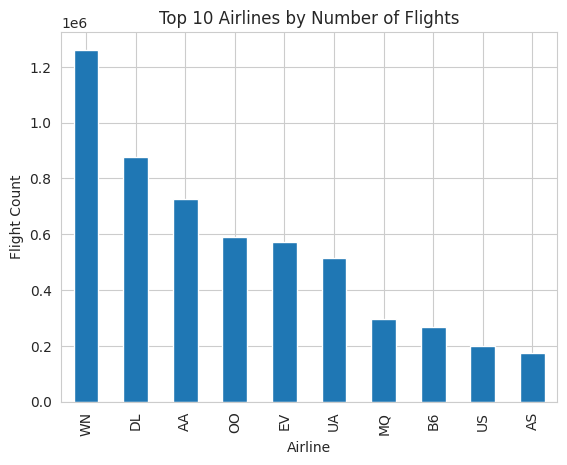

In [ ]:
top_airlines = df['AIRLINE'].value_counts().head(10)

top_airlines.plot(kind='bar')
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Flight Count")
plt.show()

BUSIEST MONTH

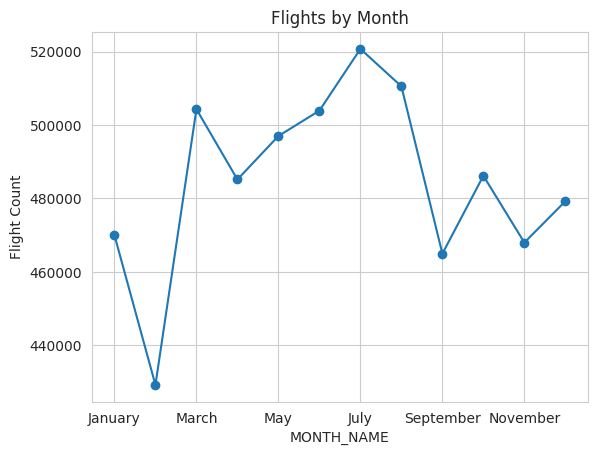

In [ ]:
df['MONTH_NAME'].value_counts().reindex(
    ['January','February','March','April','May','June',
     'July','August','September','October','November','December']
).plot(kind='line', marker='o')

plt.title("Flights by Month")
plt.ylabel("Flight Count")
plt.show()

FLIGHTS BY DAY OF WEEK

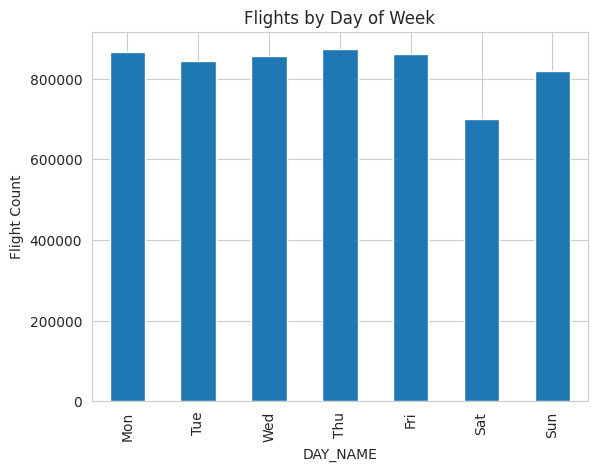

In [ ]:
df['DAY_NAME'].value_counts().reindex(
    ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
).plot(kind='bar')

plt.title("Flights by Day of Week")
plt.ylabel("Flight Count")
plt.show()

FLIGHTS BY TIME OF DAY

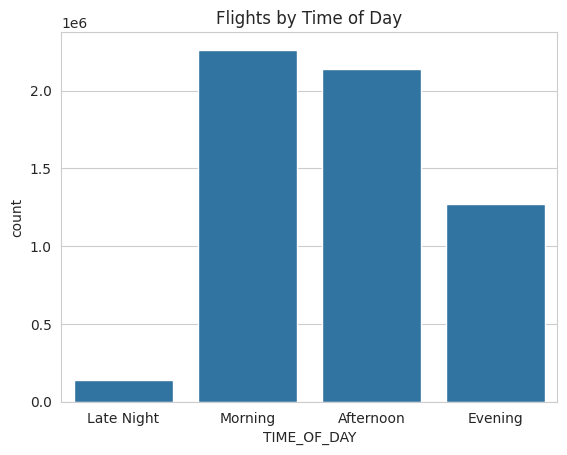

In [ ]:
sns.countplot(data=df, x='TIME_OF_DAY',
              order=['Late Night','Morning','Afternoon','Evening'])

plt.title("Flights by Time of Day")
plt.show()

BUSIEST ORIGIN AIRPORT

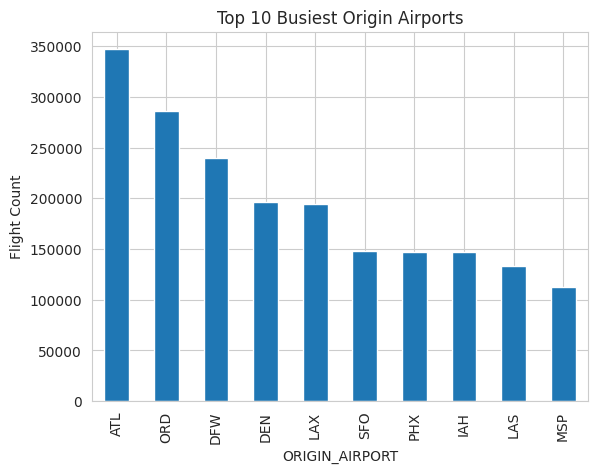

In [ ]:
df['ORIGIN_AIRPORT'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Busiest Origin Airports")
plt.ylabel("Flight Count")
plt.show()

DELAY ANALYSIS

Average Departure Delay by Airline

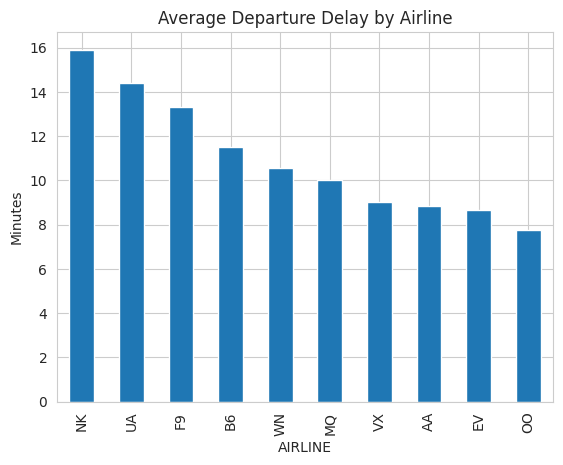

In [ ]:
df_delay.groupby('AIRLINE', observed=False)['DEPARTURE_DELAY'].mean().sort_values(
    ascending=False).head(10).plot(kind='bar')

plt.title("Average Departure Delay by Airline")
plt.ylabel("Minutes")
plt.show()

Delay Causes Comparison

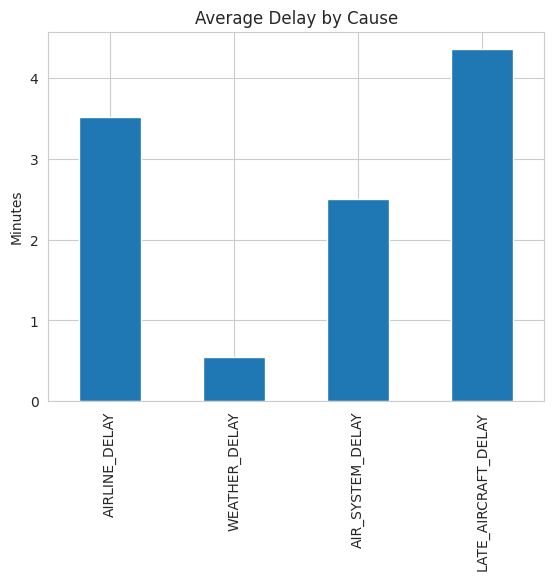

In [ ]:
delay_causes = df_delay[['AIRLINE_DELAY','WEATHER_DELAY',
                         'AIR_SYSTEM_DELAY','LATE_AIRCRAFT_DELAY']].mean()

delay_causes.plot(kind='bar')
plt.title("Average Delay by Cause")
plt.ylabel("Minutes")
plt.show()

Delay by Time of Day

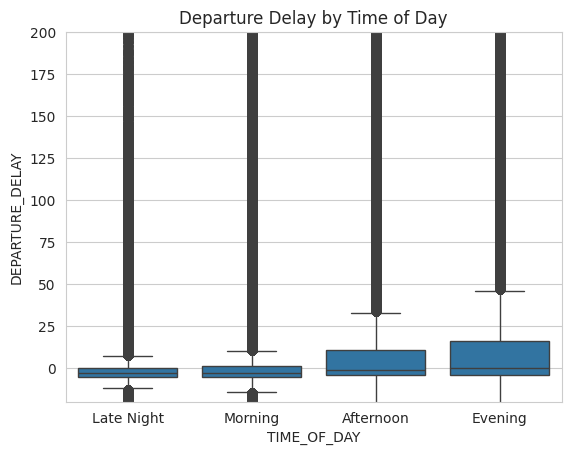

In [ ]:
sns.boxplot(data=df[df['CANCELLED'] == 0], x='TIME_OF_DAY', y='DEPARTURE_DELAY',
            order=['Late Night','Morning','Afternoon','Evening'])

plt.title("Departure Delay by Time of Day")
plt.ylim(-20,200)
plt.show()

Route-Level Delay

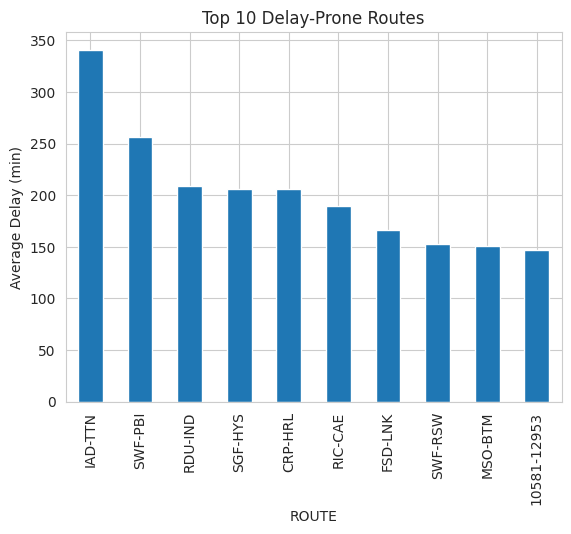

In [ ]:
df_delay.groupby('ROUTE')['DEPARTURE_DELAY'].mean().sort_values(
    ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Delay-Prone Routes")
plt.ylabel("Average Delay (min)")
plt.show()

# MILESTONE 3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
df = pd.read_csv("/content/flights_cleaned.csv")
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,...,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,MONTH_NAME,DAY_NAME,DEP_HOUR,ROUTE,DELAY_STATUS
0,2015,1,1,4,AS,ANC,SEA,5,2354.0,-11.0,...,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,ANC-SEA,On Time
1,2015,1,1,4,AA,LAX,PBI,10,2.0,-8.0,...,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,LAX-PBI,On Time
2,2015,1,1,4,US,SFO,CLT,20,18.0,-2.0,...,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,SFO-CLT,On Time
3,2015,1,1,4,AA,LAX,MIA,20,15.0,-5.0,...,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,LAX-MIA,On Time
4,2015,1,1,4,AS,SEA,ANC,25,24.0,-1.0,...,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,0,SEA-ANC,On Time


In [ ]:
winter_months = [12, 1, 2]
df["IS_WINTER"] = df["MONTH"].isin(winter_months)

seasonal_cancel = (
    df.groupby("IS_WINTER")["CANCELLED"]
    .sum()
    .reset_index()
)

seasonal_cancel["Season"] = seasonal_cancel["IS_WINTER"].map(
    {True: "Winter", False: "Non-Winter"}
)

Airport-Level Delay Heatmap

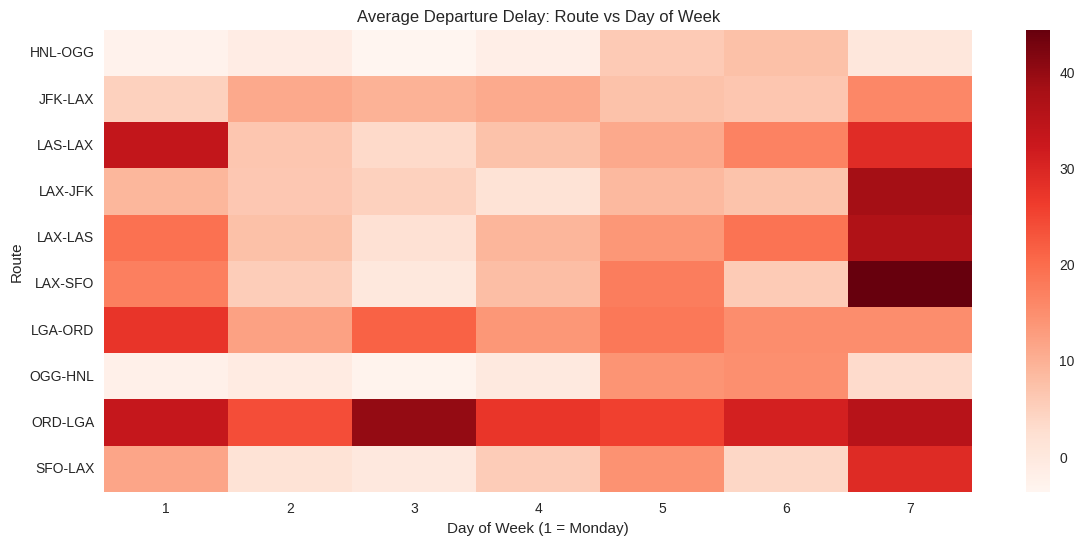

In [ ]:
top_routes_list = df["ROUTE"].value_counts().head(10).index

pivot_route_dow = df[df["ROUTE"].isin(top_routes_list)].pivot_table(
    values="DEPARTURE_DELAY",
    index="ROUTE",
    columns="DAY_OF_WEEK",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot_route_dow, cmap="Reds")
plt.title("Average Departure Delay: Route vs Day of Week")
plt.xlabel("Day of Week (1 = Monday)")
plt.ylabel("Route")
plt.show()

Route-Level Delay Heatmap

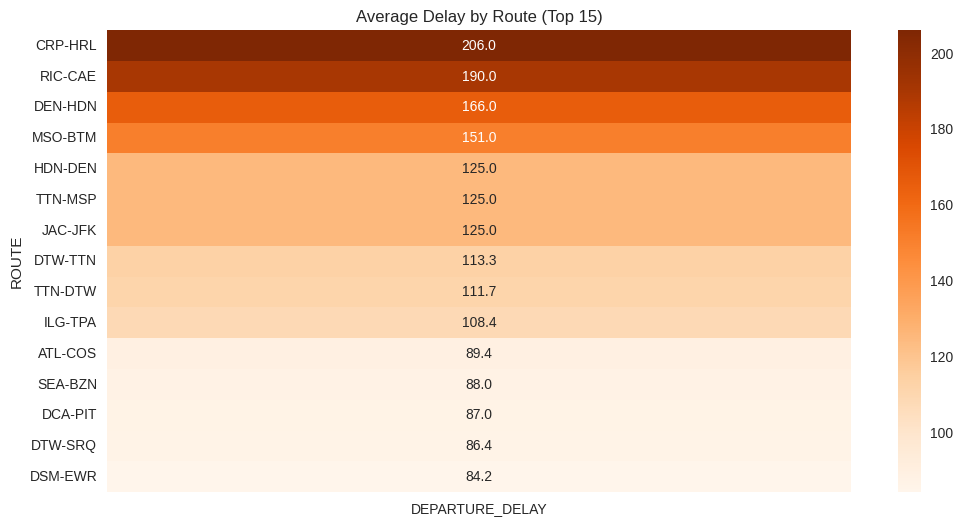

In [ ]:
route_delay = df.groupby("ROUTE")["DEPARTURE_DELAY"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
sns.heatmap(route_delay.to_frame(), cmap="Oranges", annot=True, fmt=".1f")
plt.title("Average Delay by Route (Top 15)")
plt.show()

Busiest Airports

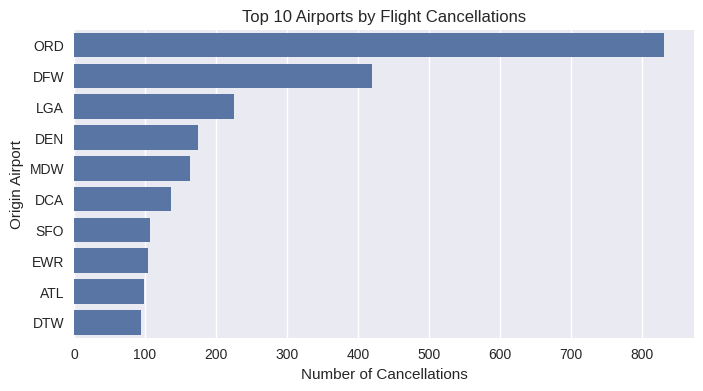

In [ ]:
airport_cancel = (
    df[df["CANCELLED"] == 1]["ORIGIN_AIRPORT"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(8,4))
sns.barplot(
    x=airport_cancel.values,
    y=airport_cancel.index
)
plt.title("Top 10 Airports by Flight Cancellations")
plt.xlabel("Number of Cancellations")
plt.ylabel("Origin Airport")
plt.show()

Cancellation Reason Analysis

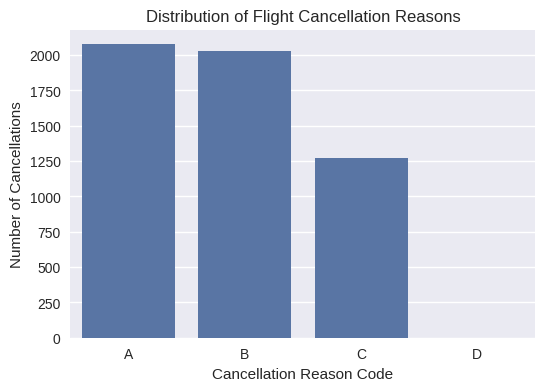

In [ ]:
cancel_df = df[df["CANCELLED"] == 1]

cancel_reason_counts = cancel_df["CANCELLATION_REASON"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(
    x=cancel_reason_counts.index,
    y=cancel_reason_counts.values
)
plt.title("Distribution of Flight Cancellation Reasons")
plt.xlabel("Cancellation Reason Code")
plt.ylabel("Number of Cancellations")
plt.show()

Cancellation Reason × Day of Week

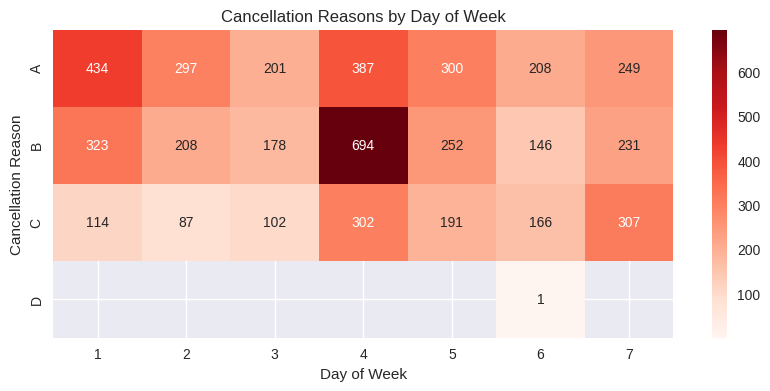

In [ ]:
pivot_cancel_dow = cancel_df.pivot_table(
    values="CANCELLED",
    index="CANCELLATION_REASON",
    columns="DAY_OF_WEEK",
    aggfunc="count"
)

plt.figure(figsize=(10,4))
sns.heatmap(pivot_cancel_dow, cmap="Reds", annot=True, fmt=".0f")
plt.title("Cancellation Reasons by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Cancellation Reason")
plt.show()

Seasonal Analysis – Winter vs Non-Winter Cancellations

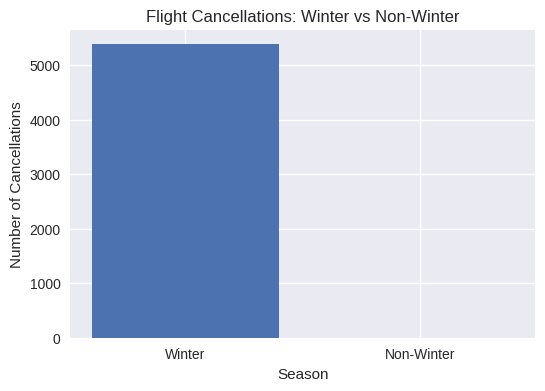

In [ ]:
df["MONTH"] = df["MONTH"].astype(int)

df["SEASON"] = df["MONTH"].apply(
    lambda x: "Winter" if x in [12, 1, 2] else "Non-Winter"
)

season_cancel = (
    df[df["CANCELLED"] == 1]
    .groupby("SEASON")
    .size()
    .reindex(["Winter", "Non-Winter"], fill_value=0)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(season_cancel.index, season_cancel.values)

plt.title("Flight Cancellations: Winter vs Non-Winter")
plt.xlabel("Season")
plt.ylabel("Number of Cancellations")

plt.show()